## Data Loading

본 프로젝트는 전자상거래 고객 행동 분석을 위해 UCI Machine Learning Repository의 **Online Retail Dataset**을 사용하였다.
- https://archive.ics.uci.edu/dataset/352/online+retail

이 데이터는 영국 기반 온라인 리테일 기업의 실제 거래 데이터를 포함하며 2010년 12월부터 2011년 12월까지의 약 1년간 거래 기록으로 구성되어 있다.

In [ ]:
import pandas as pd

df = pd.read_excel("../data/raw/Online Retail.xlsx")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Dataset Overview

데이터의 기본 구조를 확인한다.

- 총 거래 기록 수
- 컬럼 구성
- 데이터 타입


In [3]:
df.shape

(541909, 8)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [5]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## Missing Values

데이터의 결측치를 확인한다.
특히 `CustomerID` 컬럼에 많은 결측치가 존재하는데, 이는 비회원 구매 또는 고객 식별이 되지 않은 거래로 추정된다.
고객 기반 분석(RFM 분석)을 수행하기 위해 이러한 데이터는 이후 전처리 단계에서 제거할 예정이다.

In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

## Basic Dataset Statistics

데이터의 기본 규모를 파악하기 위해 다음 정보를 확인한다.

- 국가별 거래 분포
- 고객 수
- 주문 수
- 상품 수

이를 통해 데이터의 전체 구조와 거래 규모를 이해할 수 있다.

In [13]:
print("Transactions:", df.shape[0]) # 국가별 거래 분포
print("Customers:", df['CustomerID'].nunique()) # 고객 수
print("Orders:", df['InvoiceNo'].nunique()) # 주문 수
print("Products:", df['StockCode'].nunique()) # 상품 수
print("Countries:", df['Country'].nunique()) # 국가 수

Transactions: 541909
Customers: 4372
Orders: 25900
Products: 4070
Countries: 38


### Dataset Summary

- Transactions : 541,909
- Customers : 4,372
- Orders : 25,900
- Products : 4,070
- Countries : 38

대부분의 거래는 **United Kingdom**에서 발생하며 일부 유럽 국가에서도 거래가 이루어진 것을 확인할 수 있다.

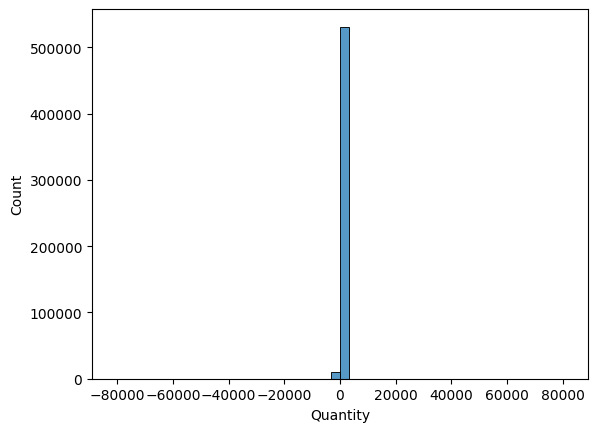

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['Quantity'], bins = 50)
plt.show()

### Quantity Distribution

거래 수량 분포를 확인한 결과 음수 값과 매우 큰 값이 존재한다.
이러한 값들은 반품 또는 취소 거래일 가능성이 있으며 분석의 정확성을 위해 이후 전처리 단계에서 제거하도록 한다.

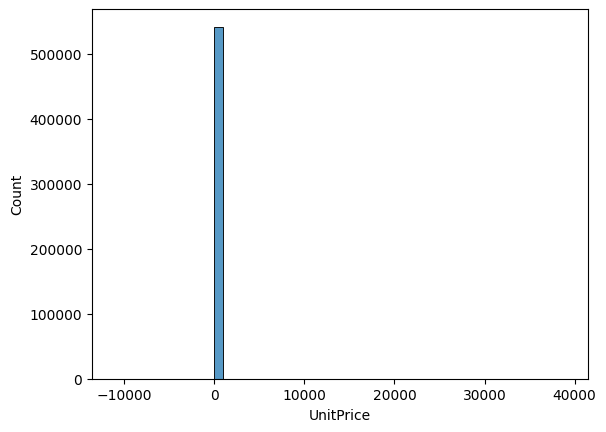

In [15]:
sns.histplot(df['UnitPrice'], bins = 50)
plt.show()

### Unit Price Distribution

상품 가격 분포를 확인한 결과 일부 음수 값과 매우 큰 값이 존재한다.
이는 취소 거래 또는 데이터 입력 오류로 판단되며 전처리 단계에서 이상값을 제거하도록 한다.

In [16]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(9288)

### Cancelled Transactions

주문번호(`InvoiceNo`)가 **C로 시작하는 거래**는 취소된 주문을 의미한다.
확인 결과 총 **9,288건의 취소 거래**가 존재하며 이러한 데이터는 실제 구매 행동을 분석하는 데 적합하지 않기 때문에 전처리 단계에서 제거하도록 한다.